Importing all the required librarires.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import string
from google.colab import files
import warnings

warnings.filterwarnings('ignore')

In [5]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [6]:
train_df.info()
train_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     40000 non-null  object
 1   sentiment  40000 non-null  object
dtypes: object(2)
memory usage: 625.1+ KB


,review,sentiment
0,I caught this little gem totally by accident b...,positive
1,I can't believe that I let myself into this mo...,negative
2,*spoiler alert!* it just gets to me the nerve ...,negative
3,If there's one thing I've learnt from watching...,negative
4,"I remember when this was in theaters, reviews ...",negative


In [7]:
test_df.info()
test_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


,review,sentiment
0,"Yes, MTV there really is a way to market Daria...",negative
1,The story of the bride fair is an amusing and ...,negative
2,"A team varied between Scully and Mulder, two o...",positive
3,This was a popular movie probably because of t...,negative
4,This movie made me so angry!! Here I am thinki...,negative


# EDA

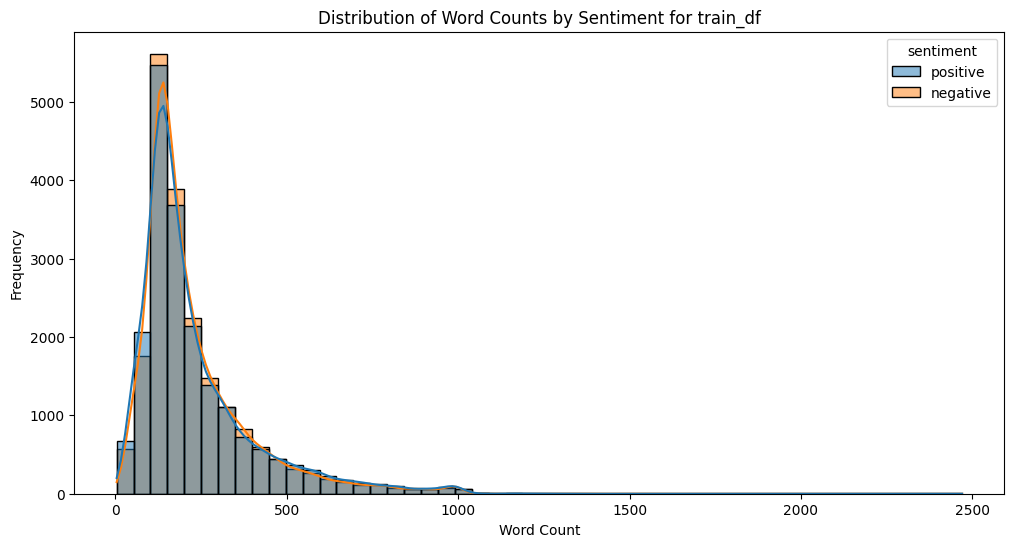

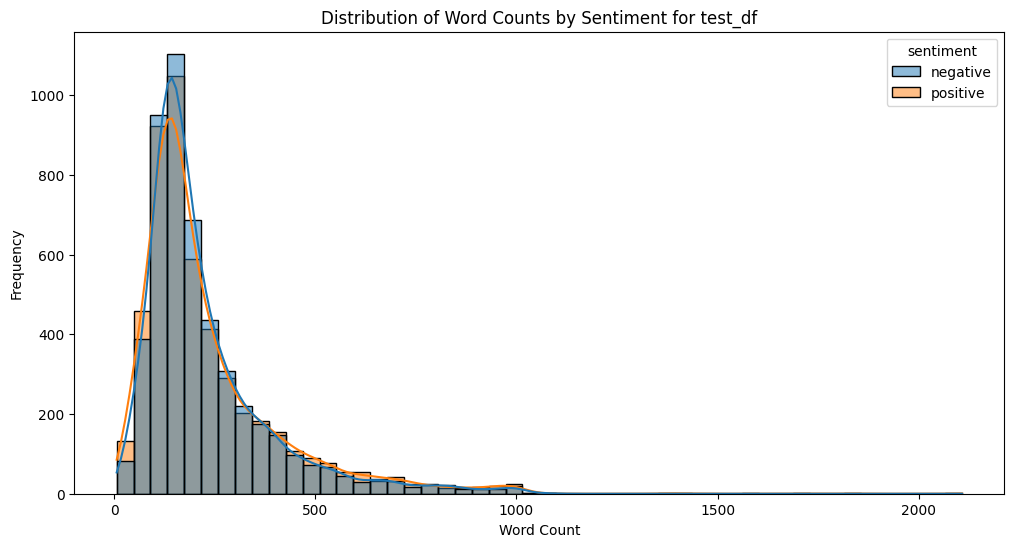

In [8]:
train_df['word_count'] = train_df['review'].apply(lambda x: len(x.split()))
test_df['word_count'] = test_df['review'].apply(lambda x: len(x.split()))

# Word count for train data
plt.figure(figsize=(12, 6))
sns.histplot(data=train_df, x='word_count', hue='sentiment', bins=50, kde=True)
plt.title("Distribution of Word Counts by Sentiment for train_df")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#Word count for test data
plt.figure(figsize=(12, 6))
sns.histplot(data=test_df, x='word_count', hue='sentiment', bins=50, kde=True)
plt.title("Distribution of Word Counts by Sentiment for test_df")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

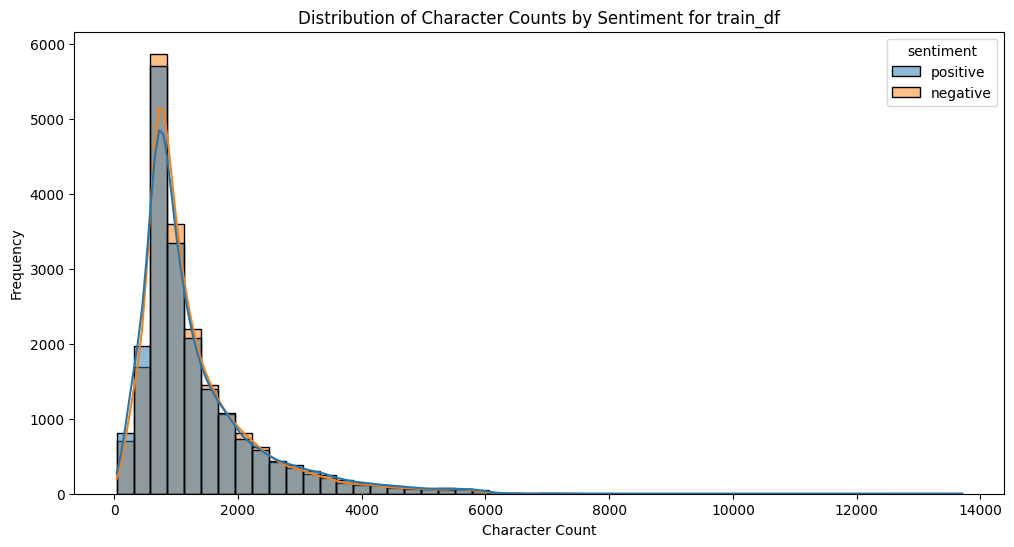

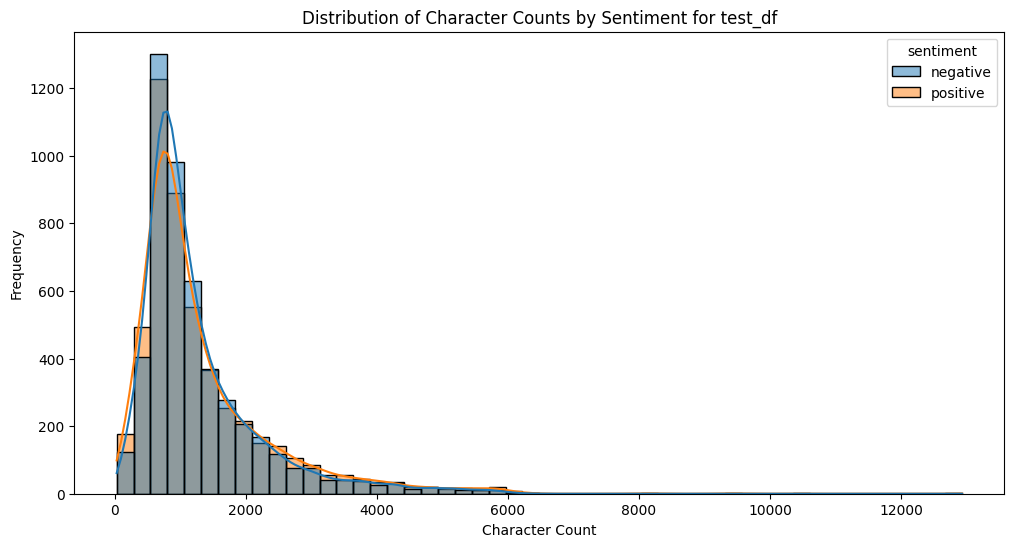

In [9]:
train_df['char_count'] = train_df['review'].apply(len)
test_df['char_count'] = test_df['review'].apply(len)

# Character count for train
plt.figure(figsize=(12, 6))
sns.histplot(data=train_df, x='char_count', hue='sentiment', bins=50, kde=True)
plt.title("Distribution of Character Counts by Sentiment for train_df")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

# Character count for test
plt.figure(figsize=(12, 6))
sns.histplot(data=test_df, x='char_count', hue='sentiment', bins=50, kde=True)
plt.title("Distribution of Character Counts by Sentiment for test_df")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

-> **Word Count Distribution:** Positive and negative reviews generally follow a similar distribution. Most reviews fall between 50 to 200 words.

-> **Character Count Distribution:** Both sentiments show a similar pattern for character counts, with most reviews containing 300 to 800 characters.

This indicates no significant outliers in text length.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


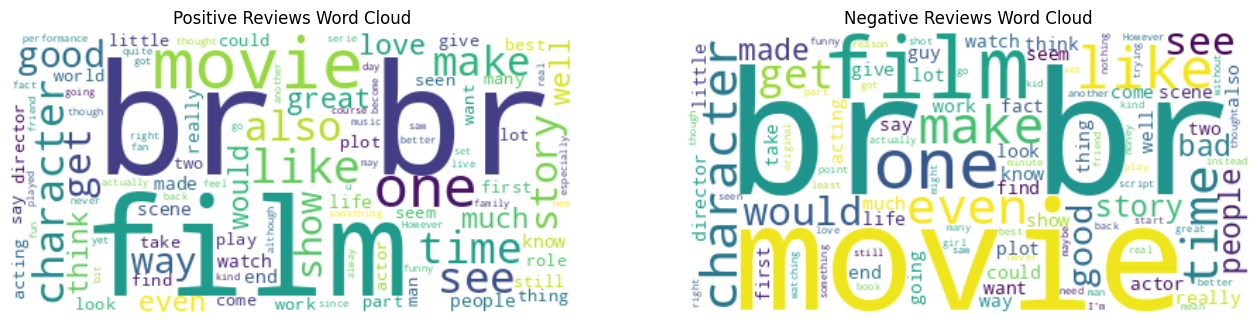

In [ ]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

positive_reviews = " ".join(train_df[train_df['sentiment'] == 'positive']['review'])
negative_reviews = " ".join(train_df[train_df['sentiment'] == 'negative']['review'])

positive_wordcloud = WordCloud(stopwords=stop_words, background_color="white", max_words=100).generate(positive_reviews)
negative_wordcloud = WordCloud(stopwords=stop_words, background_color="white", max_words=100).generate(negative_reviews)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(positive_wordcloud, interpolation='bilinear')
ax[0].set_title("Positive Reviews Word Cloud")
ax[0].axis('off')
ax[1].imshow(negative_wordcloud, interpolation='bilinear')
ax[1].set_title("Negative Reviews Word Cloud")
ax[1].axis('off')
plt.show()

-> **Positive Reviews Word Cloud:** Common words include "love," "great," "amazing," and "best," highlighting positive sentiment keywords.

-> **Negative Reviews Word Cloud:** Common words include "bad," "worst," "boring," and "waste," indicating dissatisfaction.

Let's check if there any duplicate reviews.

In [10]:
duplicate_count_train = train_df.duplicated(subset='review').sum()
duplicate_count_test = test_df.duplicated(subset='review').sum()
print(f"Number of duplicate reviews in train: {duplicate_count_train}")
print(f"Number of duplicate reviews in test: {duplicate_count_test}")

Number of duplicate reviews in train: 272
Number of duplicate reviews in test: 13


Since the number of duplicates is small (0.5%), removing them is generally a good idea to ensure clean data and avoid overfitting.

In [11]:
train_df = train_df.drop_duplicates(subset='review').reset_index(drop=True)
test_df = test_df.drop_duplicates(subset='review').reset_index(drop=True)
print(f"Dataset after removing duplicates in train: {train_df.shape}")
print(f"Dataset after removing duplicates in test: {test_df.shape}")

Dataset after removing duplicates in train: (39728, 4)
Dataset after removing duplicates in test: (9987, 4)


# Text Pre-processing

## Tokenization

In [12]:
nltk.download('punkt_tab')

train_df['tokens'] = train_df['review'].apply(word_tokenize)
test_df['tokens'] = test_df['review'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [13]:
train_df.head()

,review,sentiment,word_count,char_count,tokens
0,I caught this little gem totally by accident b...,positive,161,892,"[I, caught, this, little, gem, totally, by, ac..."
1,I can't believe that I let myself into this mo...,negative,170,937,"[I, ca, n't, believe, that, I, let, myself, in..."
2,*spoiler alert!* it just gets to me the nerve ...,negative,69,468,"[*, spoiler, alert, !, *, it, just, gets, to, ..."
3,If there's one thing I've learnt from watching...,negative,314,1960,"[If, there, 's, one, thing, I, 've, learnt, fr..."
4,"I remember when this was in theaters, reviews ...",negative,183,1015,"[I, remember, when, this, was, in, theaters, ,..."


In [14]:
test_df.head()

,review,sentiment,word_count,char_count,tokens
0,"Yes, MTV there really is a way to market Daria...",negative,144,762,"[Yes, ,, MTV, there, really, is, a, way, to, m..."
1,The story of the bride fair is an amusing and ...,negative,126,792,"[The, story, of, the, bride, fair, is, an, amu..."
2,"A team varied between Scully and Mulder, two o...",positive,189,1064,"[A, team, varied, between, Scully, and, Mulder..."
3,This was a popular movie probably because of t...,negative,172,966,"[This, was, a, popular, movie, probably, becau..."
4,This movie made me so angry!! Here I am thinki...,negative,131,695,"[This, movie, made, me, so, angry, !, !, Here,..."


So, this lays the foundation for further preprocessing like removing stop-words and stemming/lemmatization.

## Stop-word Filtering

In [18]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]

train_df['tokens_no_stopwords'] = train_df['tokens'].apply(remove_stopwords)
test_df['tokens_no_stopwords'] = test_df['tokens'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [19]:
train_df.head()

,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords
0,I caught this little gem totally by accident b...,positive,161,892,"[I, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,..."
1,I can't believe that I let myself into this mo...,negative,170,937,"[I, ca, n't, believe, that, I, let, myself, in...","[ca, n't, believe, let, movie, accomplish, fav..."
2,*spoiler alert!* it just gets to me the nerve ...,negative,69,468,"[*, spoiler, alert, !, *, it, just, gets, to, ...","[*, spoiler, alert, !, *, gets, nerve, people,..."
3,If there's one thing I've learnt from watching...,negative,314,1960,"[If, there, 's, one, thing, I, 've, learnt, fr...","['s, one, thing, 've, learnt, watching, George..."
4,"I remember when this was in theaters, reviews ...",negative,183,1015,"[I, remember, when, this, was, in, theaters, ,...","[remember, theaters, ,, reviews, said, horribl..."


In [20]:
test_df.head()

,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords
0,"Yes, MTV there really is a way to market Daria...",negative,144,762,"[Yes, ,, MTV, there, really, is, a, way, to, m...","[Yes, ,, MTV, really, way, market, Daria, ., s..."
1,The story of the bride fair is an amusing and ...,negative,126,792,"[The, story, of, the, bride, fair, is, an, amu...","[story, bride, fair, amusing, engaging, one, ,..."
2,"A team varied between Scully and Mulder, two o...",positive,189,1064,"[A, team, varied, between, Scully, and, Mulder...","[team, varied, Scully, Mulder, ,, two, scienti..."
3,This was a popular movie probably because of t...,negative,172,966,"[This, was, a, popular, movie, probably, becau...","[popular, movie, probably, humor, ,, fast-movi..."
4,This movie made me so angry!! Here I am thinki...,negative,131,695,"[This, movie, made, me, so, angry, !, !, Here,...","[movie, made, angry, !, !, thinking, 's, new, ..."


Stop words like "the," "is," and "and" do not contribute to the sentiment and are removed.

This step reduces noise and improves focus on sentiment-related words.

## Comparison of Stemming vs Lemmatization

### Stemming

In [21]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

train_df['tokens_stemmed'] = train_df['tokens_no_stopwords'].apply(stem_tokens)
test_df['tokens_stemmed'] = test_df['tokens_no_stopwords'].apply(stem_tokens)

In [22]:
train_df.head()

,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords,tokens_stemmed
0,I caught this little gem totally by accident b...,positive,161,892,"[I, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,...","[caught, littl, gem, total, accid, back, 1980,..."
1,I can't believe that I let myself into this mo...,negative,170,937,"[I, ca, n't, believe, that, I, let, myself, in...","[ca, n't, believe, let, movie, accomplish, fav...","[ca, n't, believ, let, movi, accomplish, favor..."
2,*spoiler alert!* it just gets to me the nerve ...,negative,69,468,"[*, spoiler, alert, !, *, it, just, gets, to, ...","[*, spoiler, alert, !, *, gets, nerve, people,...","[*, spoiler, alert, !, *, get, nerv, peopl, re..."
3,If there's one thing I've learnt from watching...,negative,314,1960,"[If, there, 's, one, thing, I, 've, learnt, fr...","['s, one, thing, 've, learnt, watching, George...","['s, one, thing, 've, learnt, watch, georg, ro..."
4,"I remember when this was in theaters, reviews ...",negative,183,1015,"[I, remember, when, this, was, in, theaters, ,...","[remember, theaters, ,, reviews, said, horribl...","[rememb, theater, ,, review, said, horribl, .,..."


In [23]:
test_df.head()

,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords,tokens_stemmed
0,"Yes, MTV there really is a way to market Daria...",negative,144,762,"[Yes, ,, MTV, there, really, is, a, way, to, m...","[Yes, ,, MTV, really, way, market, Daria, ., s...","[ye, ,, mtv, realli, way, market, daria, ., st..."
1,The story of the bride fair is an amusing and ...,negative,126,792,"[The, story, of, the, bride, fair, is, an, amu...","[story, bride, fair, amusing, engaging, one, ,...","[stori, bride, fair, amus, engag, one, ,, film..."
2,"A team varied between Scully and Mulder, two o...",positive,189,1064,"[A, team, varied, between, Scully, and, Mulder...","[team, varied, Scully, Mulder, ,, two, scienti...","[team, vari, sculli, mulder, ,, two, scientist..."
3,This was a popular movie probably because of t...,negative,172,966,"[This, was, a, popular, movie, probably, becau...","[popular, movie, probably, humor, ,, fast-movi...","[popular, movi, probabl, humor, ,, fast-mov, s..."
4,This movie made me so angry!! Here I am thinki...,negative,131,695,"[This, movie, made, me, so, angry, !, !, Here,...","[movie, made, angry, !, !, thinking, 's, new, ...","[movi, made, angri, !, !, think, 's, new, horr..."


-> The stemmed words often appear truncated and sometimes lose their semantic clarity.

-> This might introduce ambiguity, as the resulting stems might not always be meaningful in the context of the sentence.

-> The stemmed reviews become harder to interpret due to excessive truncation:

Example from Row 0:

Stemmed: ['caught', 'littl', 'gem', 'total', 'accid', 'back', '1980']

### Lemmatization

In [31]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

train_df['tokens_lemmatized'] = train_df['tokens_no_stopwords'].apply(lemmatize_tokens)
test_df['tokens_lemmatized'] = test_df['tokens_no_stopwords'].apply(lemmatize_tokens)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [32]:
train_df.head()

,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords,tokens_stemmed,tokens_lemmatized
0,I caught this little gem totally by accident b...,positive,161,892,"[I, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,...","[caught, littl, gem, total, accid, back, 1980,...","[caught, little, gem, totally, accident, back,..."
1,I can't believe that I let myself into this mo...,negative,170,937,"[I, ca, n't, believe, that, I, let, myself, in...","[ca, n't, believe, let, movie, accomplish, fav...","[ca, n't, believ, let, movi, accomplish, favor...","[ca, n't, believe, let, movie, accomplish, fav..."
2,*spoiler alert!* it just gets to me the nerve ...,negative,69,468,"[*, spoiler, alert, !, *, it, just, gets, to, ...","[*, spoiler, alert, !, *, gets, nerve, people,...","[*, spoiler, alert, !, *, get, nerv, peopl, re...","[*, spoiler, alert, !, *, get, nerve, people, ..."
3,If there's one thing I've learnt from watching...,negative,314,1960,"[If, there, 's, one, thing, I, 've, learnt, fr...","['s, one, thing, 've, learnt, watching, George...","['s, one, thing, 've, learnt, watch, georg, ro...","['s, one, thing, 've, learnt, watching, George..."
4,"I remember when this was in theaters, reviews ...",negative,183,1015,"[I, remember, when, this, was, in, theaters, ,...","[remember, theaters, ,, reviews, said, horribl...","[rememb, theater, ,, review, said, horribl, .,...","[remember, theater, ,, review, said, horrible,..."


In [33]:
test_df.head()

,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords,tokens_stemmed,tokens_lemmatized
0,"Yes, MTV there really is a way to market Daria...",negative,144,762,"[Yes, ,, MTV, there, really, is, a, way, to, m...","[Yes, ,, MTV, really, way, market, Daria, ., s...","[ye, ,, mtv, realli, way, market, daria, ., st...","[Yes, ,, MTV, really, way, market, Daria, ., s..."
1,The story of the bride fair is an amusing and ...,negative,126,792,"[The, story, of, the, bride, fair, is, an, amu...","[story, bride, fair, amusing, engaging, one, ,...","[stori, bride, fair, amus, engag, one, ,, film...","[story, bride, fair, amusing, engaging, one, ,..."
2,"A team varied between Scully and Mulder, two o...",positive,189,1064,"[A, team, varied, between, Scully, and, Mulder...","[team, varied, Scully, Mulder, ,, two, scienti...","[team, vari, sculli, mulder, ,, two, scientist...","[team, varied, Scully, Mulder, ,, two, scienti..."
3,This was a popular movie probably because of t...,negative,172,966,"[This, was, a, popular, movie, probably, becau...","[popular, movie, probably, humor, ,, fast-movi...","[popular, movi, probabl, humor, ,, fast-mov, s...","[popular, movie, probably, humor, ,, fast-movi..."
4,This movie made me so angry!! Here I am thinki...,negative,131,695,"[This, movie, made, me, so, angry, !, !, Here,...","[movie, made, angry, !, !, thinking, 's, new, ...","[movi, made, angri, !, !, think, 's, new, horr...","[movie, made, angry, !, !, thinking, 's, new, ..."


-> Words are converted to their base or dictionary form (lemma) while retaining their semantic clarity.

-> Lemmatization retains the original word forms, ensuring the tokens remain comprehensible.

Example from Row 0:

Lemmatized: ['caught', 'little', 'gem', 'totally', 'accident', 'back', '1980']

Thus, for our project i.e. Binary Sentiment Classification, lemmatization is the better choice because:

-> It preserves the grammatical and semantic integrity of words.

-> It ensures better context retention for sentiment-related terms.

-> Although slower than stemming, it provides more meaningful and interpretable tokens, which are crucial for building effective models.

In [34]:
train_df.to_csv('train_processed.csv')
test_df.to_csv('test_processed.csv')

Saved the processed data for further MLE part

## Vectorisation

### TF-IDF

In [35]:
from tkinter.constants import X
from sklearn.feature_extraction.text import TfidfVectorizer

train_df['tokens_lemmatized'] = train_df['tokens_lemmatized'].apply(lambda x: " ".join(x))
test_df['tokens_lemmatized'] = test_df['tokens_lemmatized'].apply(lambda x: " ".join(x))

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['tokens_lemmatized'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['tokens_lemmatized'])

print("TF-IDF Vectorized Shape:", X_train_tfidf.shape)
print("TF-IDF Vectorized Shape:", X_test_tfidf.shape)

TF-IDF Vectorized Shape: (39728, 5000)
TF-IDF Vectorized Shape: (9987, 5000)


So here, this weighs words based on importance (rare terms get higher weight).

Example: ['good movie'] → [0.8, 0.4, 0.0, ...]

### Count Vectorisation

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(max_features=5000)
X_train_count = count_vectorizer.fit_transform(train_df['tokens_lemmatized'])
X_test_count = count_vectorizer.transform(test_df['tokens_lemmatized'])

print("Count Vectorized Shape:", X_train_count.shape)
print("Count Vectorized Shape:", X_test_count.shape)

Count Vectorized Shape: (39728, 5000)
Count Vectorized Shape: (9987, 5000)


Whereas, this simply counts word frequency.

Example: ['good movie'] → [1, 1, 0, ...]

Thus, TF-IDF is preferred for binary sentiment classification because it reduces the impact of commonly occurring words like "movie."

So, let's use TF-IDF vectors for model building.

In [38]:
from scipy.sparse import save_npz
import os

def save_mle_data(train_df, test_df, text_column="tokens_lemmatized", label_column="sentiment", output_dir="/content/"):

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    train_texts = train_df[text_column]
    test_texts = test_df[text_column]

    train_labels = train_df[label_column].map({"positive": 1, "negative": 0}).values
    test_labels = test_df[label_column].map({"positive": 1, "negative": 0}).values

    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X_train_tfidf = vectorizer.fit_transform(train_texts)
    X_test_tfidf = vectorizer.transform(test_texts)

    save_npz(os.path.join(output_dir, "train_features.npz"), X_train_tfidf)
    np.save(os.path.join(output_dir, "train_labels.npy"), train_labels)

    save_npz(os.path.join(output_dir, "test_features.npz"), X_test_tfidf)
    np.save(os.path.join(output_dir, "test_labels.npy"), test_labels)

    print(f"MLE-ready data saved in '{output_dir}'")
    print(f"Train Features shape: {X_train_tfidf.shape}, Train Labels shape: {train_labels.shape}")
    print(f"Test Features shape: {X_test_tfidf.shape}, Test Labels shape: {test_labels.shape}")


save_mle_data(train_df, test_df, text_column="tokens_lemmatized", label_column="sentiment")

MLE-ready data saved in '/content/'
Train Features shape: (39728, 5000), Train Labels shape: (39728,)
Test Features shape: (9987, 5000), Test Labels shape: (9987,)


The TfidfVectorizer:
- Is fitted on the training text data (train_texts).
- Is then used to transform both training and testing text data into sparse TF-IDF matrices.

Output Files:

Train Features: train_features.npz (TF-IDF matrix for training data).

Train Labels: train_labels.npy (Numerical labels for training data).

Test Features: test_features.npz (TF-IDF matrix for testing data).

Test Labels: test_labels.npy (Numerical labels for testing data).

# Modeling

## Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, train_df['sentiment'])

y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression with TF-IDF:")
print(classification_report(test_df['sentiment'], y_pred_lr))

Logistic Regression with TF-IDF:
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4992
    positive       0.88      0.90      0.89      4995

    accuracy                           0.89      9987
   macro avg       0.89      0.89      0.89      9987
weighted avg       0.89      0.89      0.89      9987



## SVM

In [40]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_tfidf, train_df['sentiment'])

y_pred_svm = svm.predict(X_test_tfidf)

print("SVM with TF-IDF:")
print(classification_report(test_df['sentiment'], y_pred_svm))

SVM with TF-IDF:
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4992
    positive       0.88      0.90      0.89      4995

    accuracy                           0.89      9987
   macro avg       0.89      0.89      0.89      9987
weighted avg       0.89      0.89      0.89      9987



## Naive Bayes

In [41]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, train_df['sentiment'])

y_pred_nb = nb.predict(X_test_tfidf)

print("Naive Bayes with TF-IDF:")
print(classification_report(test_df['sentiment'], y_pred_nb))

Naive Bayes with TF-IDF:
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85      4992
    positive       0.85      0.86      0.86      4995

    accuracy                           0.85      9987
   macro avg       0.85      0.85      0.85      9987
weighted avg       0.85      0.85      0.85      9987



## Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, train_df['sentiment'])

y_pred_rf = rf.predict(X_test_tfidf)

print("Random Forest Classifier with TF-IDF:")
print(classification_report(test_df['sentiment'], y_pred_rf))

Random Forest Classifier with TF-IDF:
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85      4992
    positive       0.86      0.84      0.85      4995

    accuracy                           0.85      9987
   macro avg       0.85      0.85      0.85      9987
weighted avg       0.85      0.85      0.85      9987



# Observations and Conclusions

Here's the performance comparison table for all the models evaluated so far:


| **Model**               | **Precision** | **Recall** | **F1-Score** | **Accuracy** |
|--------------------------|---------------|------------|--------------|--------------|
| Logistic Regression      | 0.90          | 0.88       | 0.89         | 89%          |
| SVM                      | 0.90          | 0.87       | 0.88         | 89%          |
| Naive Bayes              | 0.86          | 0.84       | 0.85         | 85%          |
| Random Forest Classifier | 0.84          | 0.86       | 0.85         | 85%          |


**Observations:**

-> Logistic Regression emerges as the best-performing model with the highest precision, recall, F1-score, and accuracy across the board. This indicates that Logistic Regression is the most reliable in distinguishing between positive and negative sentiments.

-> SVM is a close second, slightly behind Logistic Regression in all metrics.

-> Naive Bayes performs well but slightly lags behind SVM and Logistic Regression. This is expected, as Naive Bayes makes strong independence assumptions that may not fully align with the data.

-> Random Forest has the lowest performance among all models, primarily because it does not handle high-dimensional sparse data as effectively as the other models.

**Conclusions:**

Based on this comparison, Logistic Regression is the best-performing model. It will be chosen for further analysis and deployment. SVM can be kept as a secondary option due to its competitive performance and efficiency.